In [ ]:
## Yiğit Şevki Kaplan
## 22243810049
## 17.12.2025
## WEEK 13 - K-Means Clustering

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# no label, 2 different potential X's. We want to classify the customers.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.rename(columns = {'Annual Income (k$)' : 'Income', 'Spending Score (1-100)' : 'Score'}, inplace = True)

In [ ]:
# renamed the colums "Annual Income (k$" => 'Income' AND "Spending Score (1-100)" => "Score"

In [ ]:
df.drop(['CustomerID'], axis = 1, inplace = True)

In [ ]:
df.head()

,Gender,Age,Income,Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


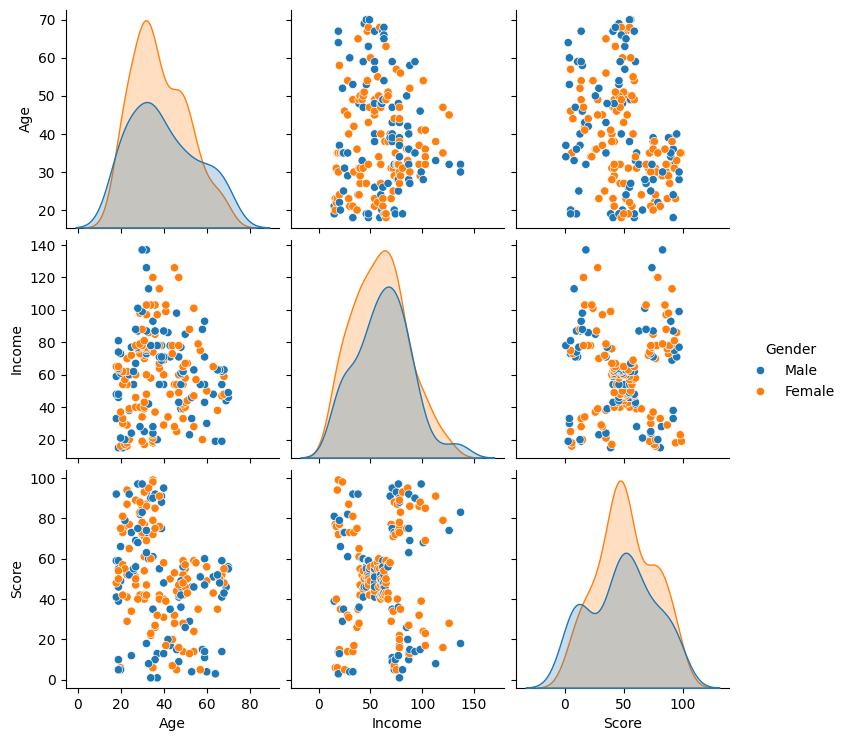

In [ ]:
sns.pairplot(df, hue='Gender')

In [ ]:
X = df.drop(['Gender'], axis = 1)

In [ ]:
X.head()

,Age,Income,Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
km3 = KMeans(n_clusters = 3).fit(X)

In [ ]:
X['Labels']=km3.labels_

In [ ]:
X.head()

,Age,Income,Score,Labels
0,19,15,39,1
1,21,15,81,1
2,20,16,6,1
3,23,16,77,1
4,31,17,40,1


Text(0.5, 1.0, 'Kmeans with 3 Clusters')

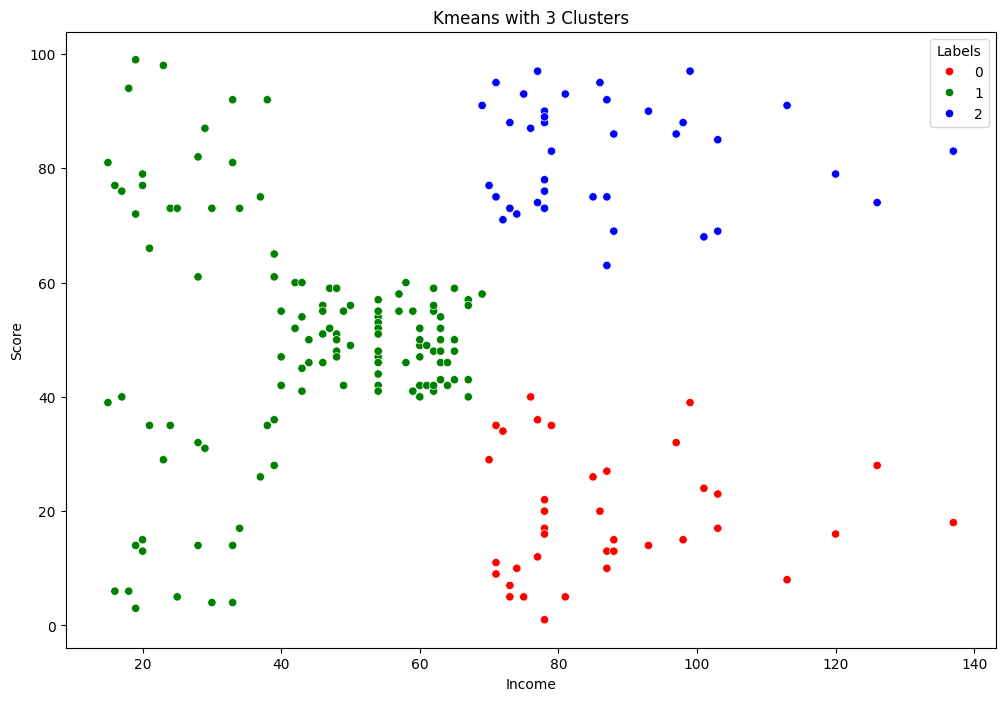

In [ ]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = X['Income'], y = X['Score'], hue = X['Labels'], palette = ['red', 'green', 'blue'])
plt.title('Kmeans with 3 Clusters')

In [ ]:
clusters = []

for i in range(1,11):
  km = KMeans(n_clusters = i).fit(X)
  clusters.append(km.inertia_)

Text(0, 0.5, 'Inertia')

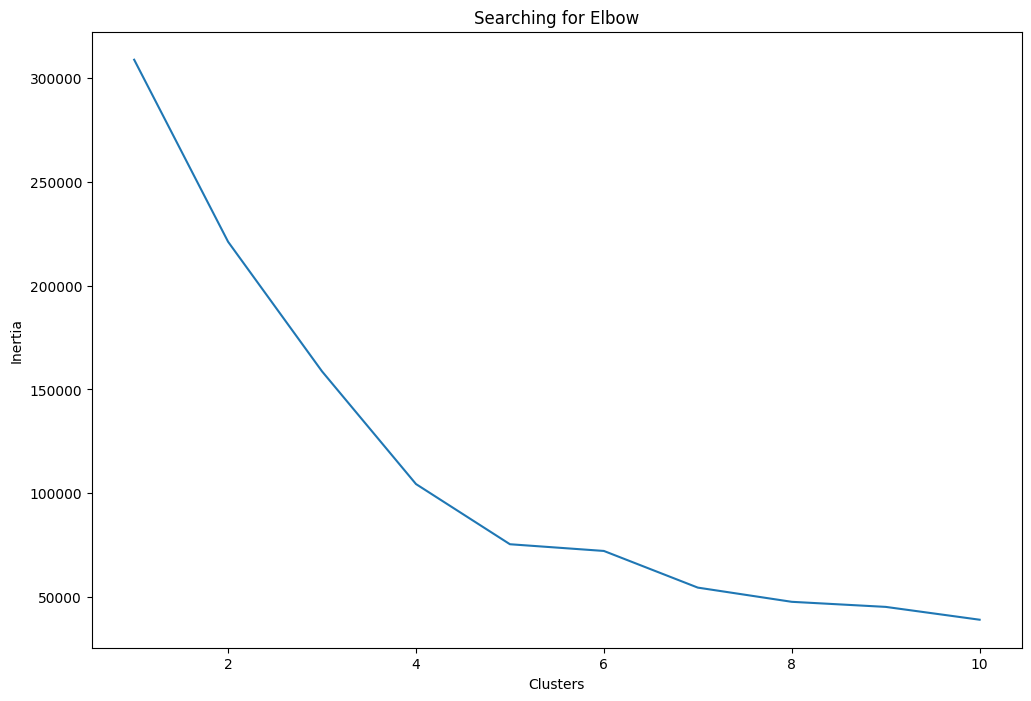

In [ ]:
fig,ax = plt.subplots(figsize = (12,8))
sns.lineplot(x = list(range(1,11)), y = clusters, ax=ax)
ax.set_title('Searching for Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')

In [ ]:
# Elbow grafiğini otomatik yapacak kütüphane.

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
visualizer = KElbowVisualizer(KMeans(), k = (2,11), randomstate = 101)

KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=10), k=(2, 11))

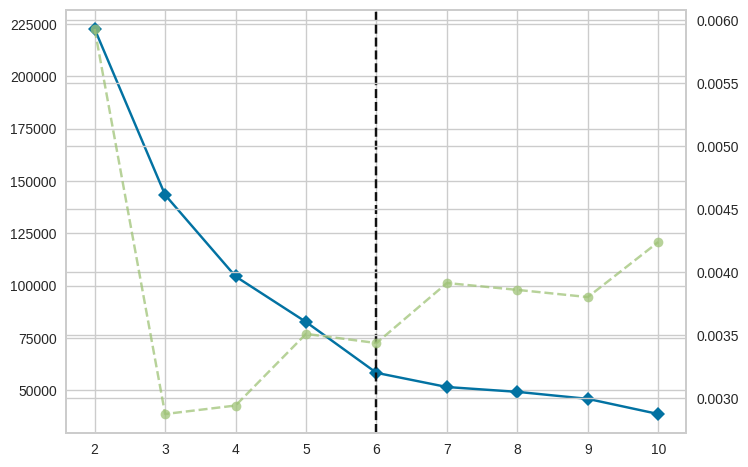

In [ ]:
visualizer.fit(X)

In [ ]:
#Number of Clusters 6.

In [ ]:
# Now we assume number of cluster = 5.

In [ ]:
X2 = df.drop(['Gender'], axis = 1)

In [ ]:
km5 = KMeans(n_clusters = 5).fit(X2)

In [ ]:
X2['Labels']=km5.labels_

In [ ]:
X2.head()

,Age,Income,Score,Labels
0,19,15,39,3
1,21,15,81,2
2,20,16,6,3
3,23,16,77,2
4,31,17,40,3


Text(0.5, 1.0, 'Kmeans with 5 Clusters')

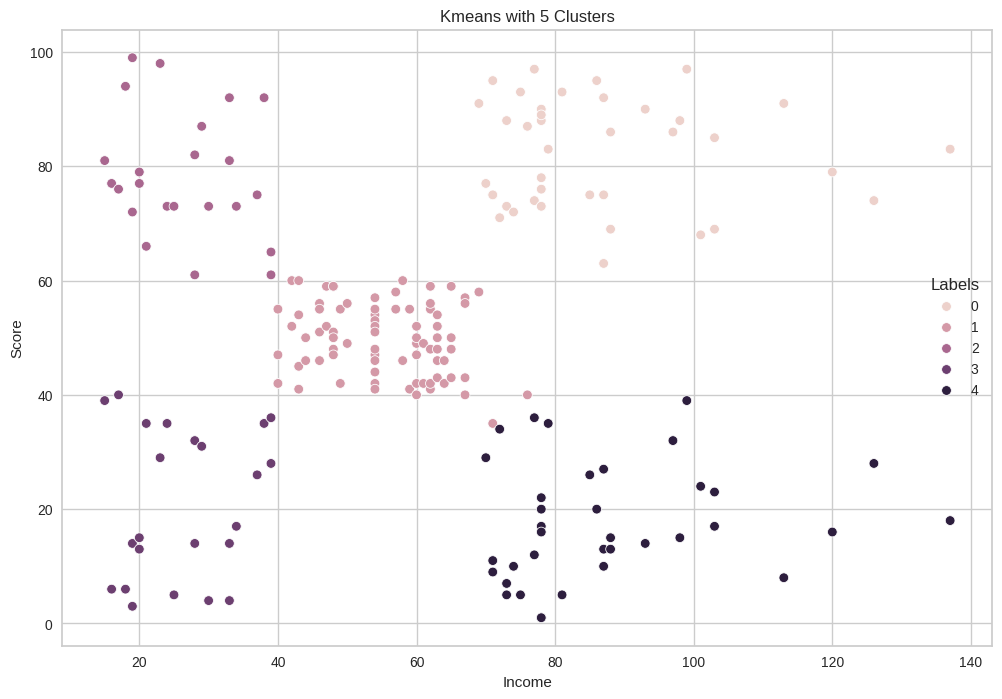

In [ ]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = X2['Income'], y = X2['Score'], hue = X2['Labels'])
plt.title('Kmeans with 5 Clusters')